In [1]:
import os
import time
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")

train = pd.read_csv("../data/processed/train.csv").dropna()
test = pd.read_csv("../data/processed/test.csv").dropna()
X_train, y_train = train["text_clean"], train["label"]
X_test, y_test = test["text_clean"], test["label"]

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cache = tempfile.mkdtemp()   # le TF-IDF n'est calculé qu'une fois par pli : gain de temps


def top_resultats(gs, n=10):
    r = pd.DataFrame(gs.cv_results_)
    cols = [c for c in r.columns if c.startswith("param_")] + ["mean_test_score", "std_test_score", "rank_test_score"]
    return r[cols].sort_values("rank_test_score").head(n).round(4)


def evaluer_test(nom, modele, f1_cv, temps, fichier_image):
    y_pred = modele.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rap = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Accuracy  : {acc:.4f}")
    print(f"Précision : {prec:.4f}")
    print(f"Rappel    : {rap:.4f}")
    print(f"F1-score  : {f1:.4f}\n")
    print(classification_report(y_test, y_pred, target_names=["Non-spam", "Spam"], digits=4))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ConfusionMatrixDisplay(cm, display_labels=["Non-spam", "Spam"]).plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Matrice de confusion : {nom}")
    ax.grid(False)
    plt.tight_layout()
    plt.savefig(fichier_image, dpi=150)
    plt.show()
    tn, fp, fn, tp = cm.ravel()
    print(f"Faux positifs : {fp} | Faux négatifs : {fn}")

    ligne = {"modèle": nom, "accuracy": acc, "précision": prec, "rappel": rap, "f1": f1,
             "faux_positifs": int(fp), "faux_négatifs": int(fn),
             "f1_validation_croisée": f1_cv, "temps_entraînement_s": round(temps, 2)}
    chemin = "../data/processed/resultats.csv"
    res = pd.read_csv(chemin)
    res = res[res["modèle"] != nom]
    res = pd.concat([res, pd.DataFrame([ligne])], ignore_index=True)
    res.to_csv(chemin, index=False)

In [2]:
pipe_svm = Pipeline([
    ("tfidf", TfidfVectorizer(min_df=3, max_df=0.95, max_features=50000)),
    ("svm", LinearSVC(random_state=42))
], memory=cache)

grille_svm = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],   # mots seuls, ou mots + paires de mots
    "svm__C": [0.1, 0.3, 1, 3, 10],           # force de régularisation (petit C = plus régularisé)
}

gs_svm = GridSearchCV(pipe_svm, grille_svm, cv=cv5, scoring="f1", n_jobs=-1, verbose=1)
debut = time.time()
gs_svm.fit(X_train, y_train)
print(f"Durée de la recherche : {time.time() - debut:.0f} s")
print("Meilleurs paramètres :", gs_svm.best_params_)
print(f"Meilleur F1 (validation croisée) : {gs_svm.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Durée de la recherche : 73 s
Meilleurs paramètres : {'svm__C': 1, 'tfidf__ngram_range': (1, 2)}
Meilleur F1 (validation croisée) : 0.9910


In [3]:
top_resultats(gs_svm)

,param_svm__C,param_tfidf__ngram_range,mean_test_score,std_test_score,rank_test_score
5,1.0,"(1, 2)",0.9910,0.0012,1
7,3.0,"(1, 2)",0.9907,0.0013,2
6,3.0,"(1, 1)",0.9902,0.0009,3
9,10.0,"(1, 2)",0.9901,0.0012,4
4,1.0,"(1, 1)",0.9899,0.0005,5
3,0.3,"(1, 2)",0.9892,0.0013,6
8,10.0,"(1, 1)",0.9891,0.0009,7
2,0.3,"(1, 1)",0.9887,0.0003,8
1,0.1,"(1, 2)",0.9872,0.0010,9
0,0.1,"(1, 1)",0.9860,0.0009,10


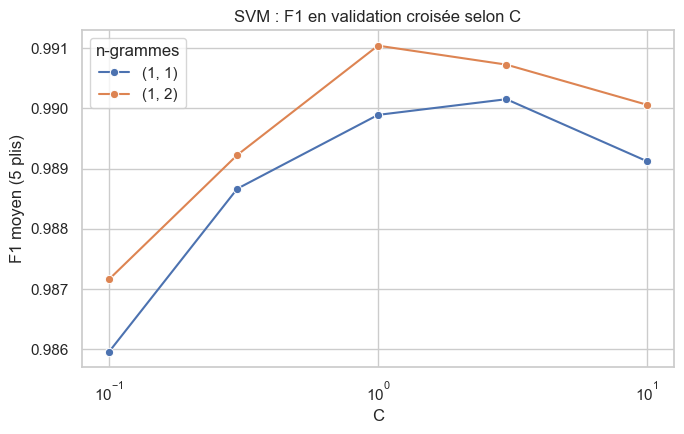

In [4]:
r = pd.DataFrame(gs_svm.cv_results_)
r["C"] = r["param_svm__C"].astype(float)
r["n-grammes"] = r["param_tfidf__ngram_range"].astype(str)

plt.figure(figsize=(7, 4.5))
sns.lineplot(data=r, x="C", y="mean_test_score", hue="n-grammes", marker="o")
plt.xscale("log")
plt.title("SVM : F1 en validation croisée selon C")
plt.ylabel("F1 moyen (5 plis)")
plt.tight_layout()
plt.savefig("../images/08_svm_grid_search.png", dpi=150)
plt.show()

In [5]:
pipe_nb = Pipeline([
    ("tfidf", TfidfVectorizer(min_df=3, max_df=0.95, max_features=50000)),
    ("nb", MultinomialNB())
], memory=cache)

grille_nb = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "nb__alpha": [0.01, 0.03, 0.1, 0.3, 1.0],   # lissage de Laplace
}

gs_nb = GridSearchCV(pipe_nb, grille_nb, cv=cv5, scoring="f1", n_jobs=-1, verbose=1)
debut = time.time()
gs_nb.fit(X_train, y_train)
print(f"Durée de la recherche : {time.time() - debut:.0f} s")
print("Meilleurs paramètres :", gs_nb.best_params_)
print(f"Meilleur F1 (validation croisée) : {gs_nb.best_score_:.4f}")
top_resultats(gs_nb)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Durée de la recherche : 13 s
Meilleurs paramètres : {'nb__alpha': 0.01, 'tfidf__ngram_range': (1, 2)}
Meilleur F1 (validation croisée) : 0.9887


,param_nb__alpha,param_tfidf__ngram_range,mean_test_score,std_test_score,rank_test_score
1,0.01,"(1, 2)",0.9887,0.0011,1
5,0.10,"(1, 2)",0.9884,0.0012,2
3,0.03,"(1, 2)",0.9884,0.0013,3
2,0.03,"(1, 1)",0.9873,0.0012,4
7,0.30,"(1, 2)",0.9873,0.0013,5
4,0.10,"(1, 1)",0.9873,0.0012,6
6,0.30,"(1, 1)",0.9871,0.0009,7
0,0.01,"(1, 1)",0.9871,0.0009,8
9,1.00,"(1, 2)",0.9856,0.0007,9
8,1.00,"(1, 1)",0.9850,0.0008,10


In [6]:
pipe_rf = Pipeline([
    ("tfidf", TfidfVectorizer(min_df=3, max_df=0.95, max_features=50000)),
    ("rf", RandomForestClassifier(n_jobs=-1, random_state=42))
], memory=cache)

distrib_rf = {
    "rf__n_estimators": [100, 200, 300],
    "rf__max_depth": [None, 50, 100, 200],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", "log2"],
}

rs_rf = RandomizedSearchCV(pipe_rf, distrib_rf, n_iter=8, cv=cv3, scoring="f1",
                           random_state=42, n_jobs=1, verbose=2)
debut = time.time()
rs_rf.fit(X_train, y_train)
print(f"Durée de la recherche : {time.time() - debut:.0f} s")
print("Meilleurs paramètres :", rs_rf.best_params_)
print(f"Meilleur F1 (validation croisée, 3 plis) : {rs_rf.best_score_:.4f}")
top_resultats(rs_rf, n=8)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END rf__max_depth=None, rf__max_features=sqrt, rf__min_samples_leaf=2, rf__n_estimators=200; total time=   7.7s
[CV] END rf__max_depth=None, rf__max_features=sqrt, rf__min_samples_leaf=2, rf__n_estimators=200; total time=   7.7s
[CV] END rf__max_depth=None, rf__max_features=sqrt, rf__min_samples_leaf=2, rf__n_estimators=200; total time=   7.7s
[CV] END rf__max_depth=200, rf__max_features=sqrt, rf__min_samples_leaf=4, rf__n_estimators=300; total time=   3.9s
[CV] END rf__max_depth=200, rf__max_features=sqrt, rf__min_samples_leaf=4, rf__n_estimators=300; total time=   4.0s
[CV] END rf__max_depth=200, rf__max_features=sqrt, rf__min_samples_leaf=4, rf__n_estimators=300; total time=   4.0s
[CV] END rf__max_depth=50, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__n_estimators=100; total time=   2.5s
[CV] END rf__max_depth=50, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__n_estimators=100; total time=   2.6s
[CV] END rf

,param_rf__n_estimators,param_rf__min_samples_leaf,param_rf__max_features,param_rf__max_depth,mean_test_score,std_test_score,rank_test_score
6,200,1,log2,None,0.9849,0.0012,1
3,100,1,sqrt,None,0.9825,0.0002,2
0,200,2,sqrt,None,0.9823,0.0005,3
5,300,2,log2,100,0.9816,0.0021,4
1,300,4,sqrt,200,0.9796,0.0012,5
2,100,1,sqrt,50,0.9750,0.0012,6
4,200,1,log2,50,0.9609,0.0077,7
7,200,4,log2,50,0.9552,0.0081,8


=== SVM optimisé ===
Accuracy  : 0.9916
Précision : 0.9876
Rappel    : 0.9946
F1-score  : 0.9911

              precision    recall  f1-score   support

    Non-spam     0.9952    0.9889    0.9921      3159
        Spam     0.9876    0.9946    0.9911      2795

    accuracy                         0.9916      5954
   macro avg     0.9914    0.9918    0.9916      5954
weighted avg     0.9916    0.9916    0.9916      5954



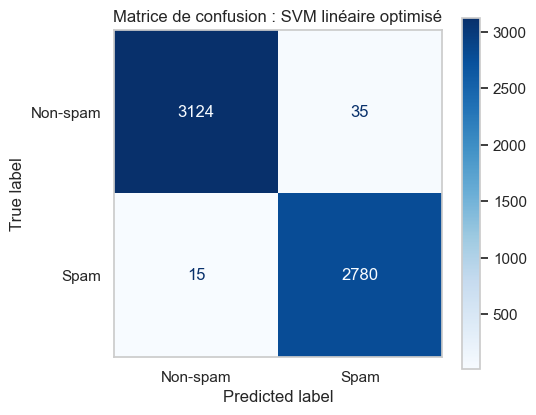

Faux positifs : 35 | Faux négatifs : 15


In [7]:
print("=== SVM optimisé ===")
evaluer_test("SVM linéaire optimisé", gs_svm.best_estimator_, gs_svm.best_score_,
             gs_svm.refit_time_, "../images/08_matrice_confusion_svm_opt.png")

=== Naive Bayes optimisé ===
Accuracy  : 0.9899
Précision : 0.9886
Rappel    : 0.9900
F1-score  : 0.9893

              precision    recall  f1-score   support

    Non-spam     0.9911    0.9899    0.9905      3159
        Spam     0.9886    0.9900    0.9893      2795

    accuracy                         0.9899      5954
   macro avg     0.9898    0.9899    0.9899      5954
weighted avg     0.9899    0.9899    0.9899      5954



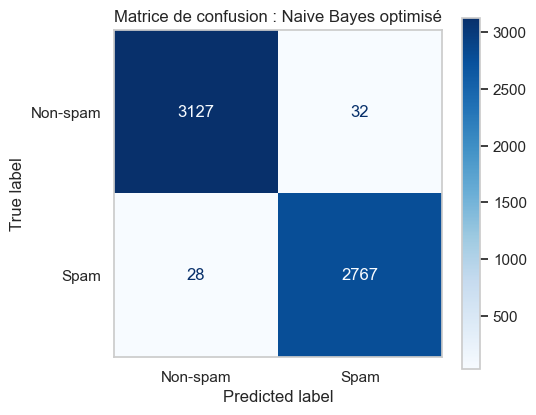

Faux positifs : 32 | Faux négatifs : 28


In [8]:
print("=== Naive Bayes optimisé ===")
evaluer_test("Naive Bayes optimisé", gs_nb.best_estimator_, gs_nb.best_score_,
             gs_nb.refit_time_, "../images/08_matrice_confusion_nb_opt.png")

=== Random Forest optimisé ===
Accuracy  : 0.9847
Précision : 0.9808
Rappel    : 0.9868
F1-score  : 0.9838

              precision    recall  f1-score   support

    Non-spam     0.9882    0.9829    0.9856      3159
        Spam     0.9808    0.9868    0.9838      2795

    accuracy                         0.9847      5954
   macro avg     0.9845    0.9848    0.9847      5954
weighted avg     0.9847    0.9847    0.9847      5954



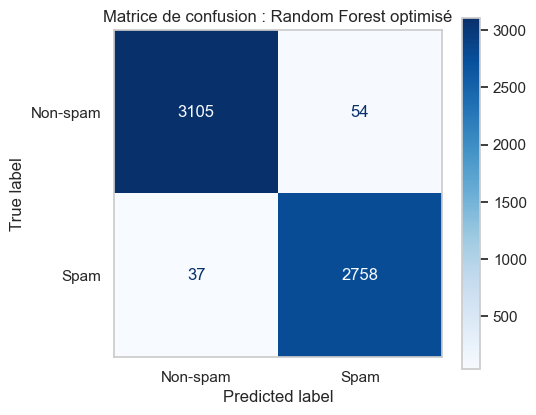

Faux positifs : 54 | Faux négatifs : 37


In [9]:
print("=== Random Forest optimisé ===")
evaluer_test("Random Forest optimisé", rs_rf.best_estimator_, rs_rf.best_score_,
             rs_rf.refit_time_, "../images/08_matrice_confusion_rf_opt.png")

In [10]:
res = pd.read_csv("../data/processed/resultats.csv")
res["erreurs_totales"] = res["faux_positifs"] + res["faux_négatifs"]
res.sort_values("f1", ascending=False).round(4)

,modèle,accuracy,précision,rappel,f1,faux_positifs,faux_négatifs,f1_validation_croisée,temps_entraînement_s,erreurs_totales
5,SVM linéaire optimisé,0.9916,0.9876,0.9946,0.9911,35,15,0.9910,13.93,50
1,SVM linéaire + TF-IDF,0.9903,0.9837,0.9957,0.9897,46,12,0.9899,3.94,58
6,Naive Bayes optimisé,0.9899,0.9886,0.9900,0.9893,32,28,0.9887,0.69,60
0,Naive Bayes + TF-IDF,0.9871,0.9885,0.9839,0.9862,32,45,0.9850,4.40,77
4,"DistilBERT (10000 emails, 2 époques)",0.9869,0.9860,0.9860,0.9860,39,39,NaN,205.80,78
2,Random Forest + TF-IDF,0.9851,0.9771,0.9914,0.9842,65,24,0.9842,11.90,89
7,Random Forest optimisé,0.9847,0.9808,0.9868,0.9838,54,37,0.9849,11.37,91
3,Word2Vec + Régression logistique,0.9807,0.9722,0.9871,0.9796,79,36,0.9779,37.78,115
